# 🔤 Assamese OCR — Sentence Model Training (Kaggle)

This notebook trains a CRNN (CNN + LSTM) model for Assamese sentence-level OCR using CTC loss.

**Before you start:**
1. Set accelerator to **GPU** → Settings (right panel) → Accelerator → GPU T4 x2
2. Add your dataset containing `as-wiki-2021.txt` as a Kaggle Dataset input
3. (Optional) Add a dataset with your existing checkpoints `.pth` files

**Kaggle paths:**
- Input datasets: `/kaggle/input/<dataset-slug>/`
- Working directory (writable): `/kaggle/working/`
- Checkpoints will be saved to `/kaggle/working/checkpoints/`

---

## 1. Setup — Clone Repo & Install Dependencies

In [1]:
import os

REPO_URL    = "https://github.com/rishav660/Assamese_OCR.git"
REPO_NAME   = "Assamese_OCR"
BRANCH      = "develop"
WORK_DIR    = f'/kaggle/working/{REPO_NAME}/django_backend'

# Clone or pull latest
if not os.path.exists(f'/kaggle/working/{REPO_NAME}'):
    !git clone -b {BRANCH} {REPO_URL} /kaggle/working/{REPO_NAME}
else:
    print(f'Repo already exists — pulling latest changes...')
    !cd /kaggle/working/{REPO_NAME} && git checkout {BRANCH} && git pull

# Switch to working directory
%cd {WORK_DIR}
!pwd

Cloning into '/kaggle/working/Assamese_OCR'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (91/91), done.
remote: Total 116 (delta 61), reused 73 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (116/116), 5.87 MiB | 16.64 MiB/s, done.
Resolving deltas: 100% (61/61), done.
/kaggle/working/Assamese_OCR/django_backend
/kaggle/working/Assamese_OCR/django_backend


In [2]:
# Install dependencies
!pip install -q -r requirements-train.txt

In [3]:
# Verify GPU
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU detected. Enable GPU in Settings → Accelerator.')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Memory: 15.6 GB


## 2. Locate Input Data & Set Up Directories

Your `as-wiki-2021.txt` must be added as a Kaggle Dataset.

**How to add it:**
1. Upload `as-wiki-2021.txt` to a Kaggle Dataset (or use an existing one)
2. In this notebook → top-right → **+ Add Data** → search for your dataset
3. It will appear at `/kaggle/input/<your-dataset-slug>/as-wiki-2021.txt`

Update `WIKI_INPUT_PATH` below to match your dataset slug.

In [4]:
import os
import shutil

# ─── UPDATE THIS to match your Kaggle dataset slug ───────────────────────────
WIKI_INPUT_PATH = '/kaggle/input/assamese-wiki/as-wiki-2021.txt'  # ← CHANGE THIS
# ─────────────────────────────────────────────────────────────────────────────

# Verify the wiki file exists
if os.path.exists(WIKI_INPUT_PATH):
    size_mb = os.path.getsize(WIKI_INPUT_PATH) / 1e6
    print(f'✅ Wiki file found: {WIKI_INPUT_PATH} ({size_mb:.1f} MB)')
else:
    print(f'❌ Wiki file not found at: {WIKI_INPUT_PATH}')
    print('   Add your dataset via "+ Add Data" in the right panel.')

# Create local data/ and checkpoints/ directories under the working dir
os.makedirs('data', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

# Symlink wiki file into data/ for convenience
wiki_link = 'data/as-wiki-2021.txt'
if not os.path.exists(wiki_link):
    os.symlink(WIKI_INPUT_PATH, wiki_link)
    print(f'✅ Symlinked wiki file → data/as-wiki-2021.txt')
else:
    print(f'✅ data/as-wiki-2021.txt already linked')

❌ Wiki file not found at: /kaggle/input/assamese-wiki/as-wiki-2021.txt
   Add your dataset via "+ Add Data" in the right panel.
✅ data/as-wiki-2021.txt already linked


In [5]:
# (Optional) Copy existing checkpoints from a Kaggle dataset input
# Add your checkpoint dataset via "+ Add Data", then update the path below.

CHECKPOINT_INPUT = '/kaggle/input/assamese-ocr-checkpoints'  # ← CHANGE or comment out

if os.path.exists(CHECKPOINT_INPUT):
    for f in os.listdir(CHECKPOINT_INPUT):
        if f.endswith('.pth'):
            src = os.path.join(CHECKPOINT_INPUT, f)
            dst = os.path.join('checkpoints', f)
            if not os.path.exists(dst):
                shutil.copy2(src, dst)
                print(f'  Copied: {f}')
            else:
                print(f'  Already exists: {f}')
    print('✅ Checkpoints ready')
else:
    print('ℹ️  No checkpoint input dataset found — training from scratch.')

print('\nCheckpoints directory:')
!ls -lh checkpoints/ 2>/dev/null || echo '  (empty)'

ℹ️  No checkpoint input dataset found — training from scratch.

Checkpoints directory:
total 0


## 3. Generate Non-Overlapping Train / Val / Test Splits

In [6]:
# Check if splits already exist (useful if re-running the notebook)
train_labels = 'data/train_real_sentences/labels/labels.txt'
if os.path.exists(train_labels):
    with open(train_labels) as f:
        n = sum(1 for _ in f)
    print(f'✅ Splits already exist! ({n} training samples)')
    print('Skip the next cell unless you want to regenerate.')
else:
    print('❌ No splits found. Run the next cell to generate them.')

❌ No splits found. Run the next cell to generate them.


In [7]:
# Step 1: Clean up any old split directories
for split in ['train_real_sentences', 'val_real_sentences', 'test_real_sentences']:
    dst = f'data/{split}'
    if os.path.islink(dst):
        os.unlink(dst)
    elif os.path.exists(dst):
        shutil.rmtree(dst)
    os.makedirs(f'{dst}/images', exist_ok=True)
    os.makedirs(f'{dst}/labels', exist_ok=True)

print('✅ Local data directories ready')

# Step 2: Generate splits
!python build_real_sentence_splits.py \
    --input data/as-wiki-2021.txt \
    --train-output data/train_real_sentences \
    --val-output data/val_real_sentences \
    --test-output data/test_real_sentences \
    --train-count 50000 \
    --val-count 5000 \
    --test-count 2000 \
    --seed 42

# Step 3: Verify generated splits
print()
for split in ['train_real_sentences', 'val_real_sentences', 'test_real_sentences']:
    img_dir    = f'data/{split}/images'
    label_file = f'data/{split}/labels/labels.txt'
    n_images   = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    ok         = '✅' if os.path.exists(label_file) else '❌'
    print(f'{split}')
    print(f'  Images     : {n_images}')
    print(f'  labels.txt : {ok}')

print('\n✅ Dataset generation complete')

✅ Local data directories ready
✓ Loaded 8 fonts for variety
Building real sentence splits
Corpus: data/as-wiki-2021.txt
Seed: 42
Requested splits: train=50000, val=5000, test=2000
Unique valid sentences available: 91499
Filtered out: blank=0, too_short=0, too_long=8501, non_assamese=0, duplicates=0
Writing training split...
  -> Generating 50000 images using 4 CPU cores...
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default font
✓ Using default

## 4. Train the Sentence Model 🚀

In [8]:
# Main training run
!python train_sentence_model.py \
    --train-img-dir   data/train_real_sentences/images \
    --train-label-file data/train_real_sentences/labels/labels.txt \
    --val-img-dir     data/val_real_sentences/images \
    --val-label-file  data/val_real_sentences/labels/labels.txt \
    --epochs 25 \
    --batch-size 32 \
    --learning-rate 0.0001 \
    --best-checkpoint  checkpoints/best_model_sentences.pth \
    --final-checkpoint checkpoints/final_model_sentences.pth \
    --plot-out training_curve_sentences.png

Using device: cuda
Space character found in char_map at index: 1

Loading sentence datasets...
  train images : data/train_real_sentences/images
  train labels : data/train_real_sentences/labels/labels.txt
  val images   : data/val_real_sentences/images
  val labels   : data/val_real_sentences/labels/labels.txt
Data augmentation: enabled
Loading labels from data/train_real_sentences/labels/labels.txt...
Loaded 50000 unique labels.
Found 50000 image files in directory.
Matched 50000 images with labels.
Loading labels from data/val_real_sentences/labels/labels.txt...
Loaded 5000 unique labels.
Found 5000 image files in directory.
Matched 5000 images with labels.
Train sentences: 50000, Val sentences: 5000
Using 4 workers for data loading
Train batches: 1563, Val batches: 157
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|███████████████████████████████████████| 44.7M/44.7M [00:00<00:00, 168MB/s]

S

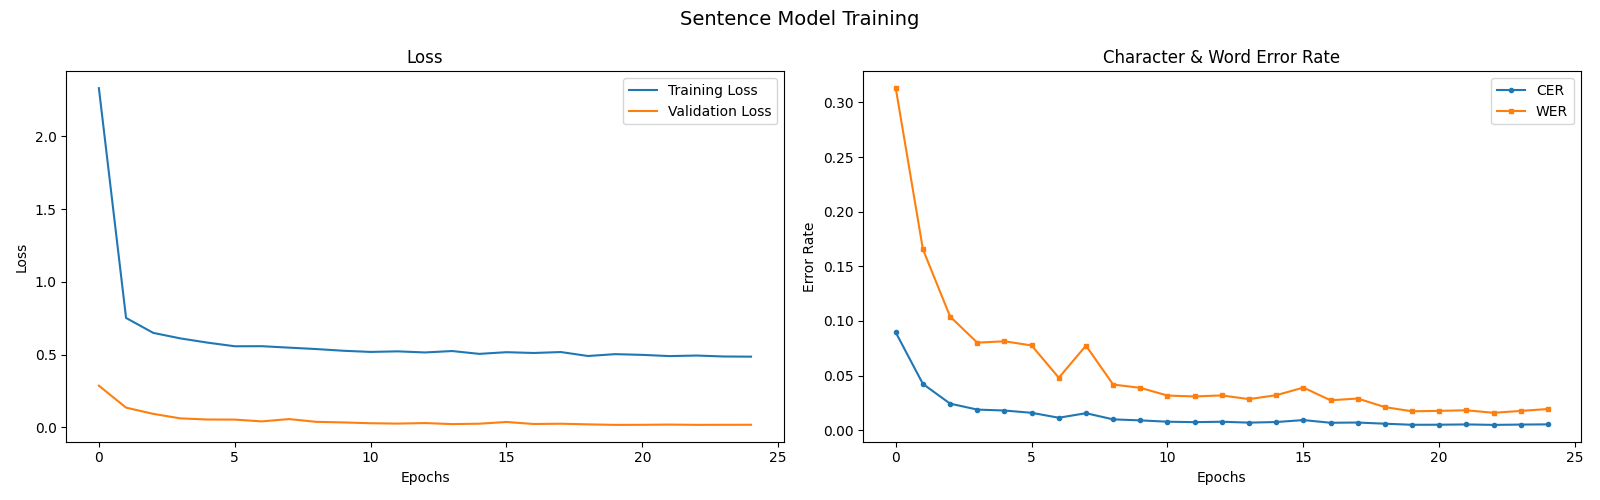

In [9]:
# View training curve
from IPython.display import Image as IPImage, display
if os.path.exists('training_curve_sentences.png'):
    display(IPImage('training_curve_sentences.png'))
else:
    print('No training curve found yet.')

## 5. Evaluate Model Accuracy (CER / WER / Exact Match)

In [10]:
# Evaluate on VALIDATION set — raw model output (greedy decode)
!python evaluate.py \
    --img-dir    data/val_real_sentences/images \
    --label-file data/val_real_sentences/labels/labels.txt \
    --checkpoint checkpoints/best_model_sentences.pth \
    --num-samples 10

Device: cuda
Loading checkpoint: checkpoints/best_model_sentences.pth
Loaded 5000 labels from data/val_real_sentences/labels/labels.txt
Found 5000 images, 5000 with labels

Evaluating 5000 images...
Decode: greedy
Post-processing: OFF

  Processed 100/5000 images...
  Processed 200/5000 images...
  Processed 300/5000 images...
  Processed 400/5000 images...
  Processed 500/5000 images...
  Processed 600/5000 images...
  Processed 700/5000 images...
  Processed 800/5000 images...
  Processed 900/5000 images...
  Processed 1000/5000 images...
  Processed 1100/5000 images...
  Processed 1200/5000 images...
  Processed 1300/5000 images...
  Processed 1400/5000 images...
  Processed 1500/5000 images...
  Processed 1600/5000 images...
  Processed 1700/5000 images...
  Processed 1800/5000 images...
  Processed 1900/5000 images...
  Processed 2000/5000 images...
  Processed 2100/5000 images...
  Processed 2200/5000 images...
  Processed 2300/5000 images...
  Processed 2400/5000 images...
  Pro

In [11]:
# Evaluate on VALIDATION set — with spell-check post-processing
# Compare with the cell above to see if post-processing helps
!python evaluate.py \
    --img-dir    data/val_real_sentences/images \
    --label-file data/val_real_sentences/labels/labels.txt \
    --checkpoint checkpoints/best_model_sentences.pth \
    --post-process \
    --num-samples 10

Device: cuda
Loading checkpoint: checkpoints/best_model_sentences.pth
Loaded 5000 labels from data/val_real_sentences/labels/labels.txt
Found 5000 images, 5000 with labels

Evaluating 5000 images...
Decode: greedy
Post-processing: ON

Loading corpus from /kaggle/working/Assamese_OCR/django_backend/data/as-wiki-2021.txt...
Loaded 152517 unique words.
  Processed 100/5000 images...
  Processed 200/5000 images...
  Processed 300/5000 images...
  Processed 400/5000 images...
  Processed 500/5000 images...
  Processed 600/5000 images...
  Processed 700/5000 images...
  Processed 800/5000 images...
  Processed 900/5000 images...
  Processed 1000/5000 images...
  Processed 1100/5000 images...
  Processed 1200/5000 images...
  Processed 1300/5000 images...
  Processed 1400/5000 images...
  Processed 1500/5000 images...
  Processed 1600/5000 images...
  Processed 1700/5000 images...
  Processed 1800/5000 images...
  Processed 1900/5000 images...
  Processed 2000/5000 images...
  Processed 2100/

In [12]:
# Evaluate on VALIDATION set — CTC Beam Search (typically better accuracy)
!python evaluate.py \
    --img-dir    data/val_real_sentences/images \
    --label-file data/val_real_sentences/labels/labels.txt \
    --checkpoint checkpoints/best_model_sentences.pth \
    --beam-width 10 \
    --num-samples 10

Device: cuda
Loading checkpoint: checkpoints/best_model_sentences.pth
Loaded 5000 labels from data/val_real_sentences/labels/labels.txt
Found 5000 images, 5000 with labels

Evaluating 5000 images...
Decode: beam search (width=10)
Post-processing: OFF

  Processed 100/5000 images...
  Processed 200/5000 images...
  Processed 300/5000 images...
  Processed 400/5000 images...
  Processed 500/5000 images...
  Processed 600/5000 images...
  Processed 700/5000 images...
  Processed 800/5000 images...
  Processed 900/5000 images...
  Processed 1000/5000 images...
  Processed 1100/5000 images...
  Processed 1200/5000 images...
  Processed 1300/5000 images...
  Processed 1400/5000 images...
  Processed 1500/5000 images...
  Processed 1600/5000 images...
  Processed 1700/5000 images...
  Processed 1800/5000 images...
  Processed 1900/5000 images...
  Processed 2000/5000 images...
  Processed 2100/5000 images...
  Processed 2200/5000 images...
  Processed 2300/5000 images...
  Processed 2400/5000

In [13]:
# Evaluate on TEST set
test_labels = 'data/test_real_sentences/labels/labels.txt'
if os.path.exists(test_labels):
    !python evaluate.py \
        --img-dir    data/test_real_sentences/images \
        --label-file {test_labels} \
        --checkpoint checkpoints/best_model_sentences.pth \
        --num-samples 10 \
        --output test_results.tsv
    print('\n✅ Detailed results saved to test_results.tsv')
else:
    print('❌ No test set found. Regenerate splits with --test-count 2000.')

Device: cuda
Loading checkpoint: checkpoints/best_model_sentences.pth
Loaded 2000 labels from data/test_real_sentences/labels/labels.txt
Found 2000 images, 2000 with labels

Evaluating 2000 images...
Decode: greedy
Post-processing: OFF

  Processed 100/2000 images...
  Processed 200/2000 images...
  Processed 300/2000 images...
  Processed 400/2000 images...
  Processed 500/2000 images...
  Processed 600/2000 images...
  Processed 700/2000 images...
  Processed 800/2000 images...
  Processed 900/2000 images...
  Processed 1000/2000 images...
  Processed 1100/2000 images...
  Processed 1200/2000 images...
  Processed 1300/2000 images...
  Processed 1400/2000 images...
  Processed 1500/2000 images...
  Processed 1600/2000 images...
  Processed 1700/2000 images...
  Processed 1800/2000 images...
  Processed 1900/2000 images...
  Processed 2000/2000 images...

EVALUATION RESULTS
Checkpoint : checkpoints/best_model_sentences.pth
Dataset    : data/test_real_sentences/images (2000 samples)
De

In [14]:
# Quick single-image prediction with ground-truth comparison
!python predict_cli.py \
    --image        data/val_real_sentences/images/sentence_000000.png \
    --checkpoint   checkpoints/best_model_sentences.pth \
    --ground-truth data/val_real_sentences/labels/sentence_000000.txt

Loading corpus from /kaggle/working/Assamese_OCR/django_backend/data/as-wiki-2021.txt...
Loaded 152517 unique words.
Decode: greedy
Prediction: ফলত উচ্চাৰণ
Ground Truth: ফলত উচ্চাৰণ কোমল হয়।
CER: 0.4762 (47.62%)
WER: 0.5000 (50.00%)
❌ Not exact


## 6. (Optional) Transfer Learning

If you have `best_model_fast.pth` in `checkpoints/`, you can fine-tune from the character model.

In [15]:
# Transfer learning — uncomment to run
# !python train_transfer_learning.py

## 7. Save Outputs

On Kaggle, anything written to `/kaggle/working/` is automatically saved as notebook output when the session ends.  
You can download your checkpoints, results, and plots from the **Output** tab after the run completes.

In [16]:
# List all saved outputs
print('=== Checkpoints ===')
!ls -lh checkpoints/ 2>/dev/null || echo '  (none)'

print('\n=== Plots & Results ===')
!ls -lh *.png *.tsv 2>/dev/null || echo '  (none)'

print()
print('✅ All files in /kaggle/working/ are available in the Output tab.')

=== Checkpoints ===
total 204M
-rw-r--r-- 1 root root 102M May 11 17:27 best_model_sentences.pth
-rw-r--r-- 1 root root 102M May 11 18:54 final_model_sentences.pth

=== Plots & Results ===
-rw-r--r-- 1 root root 785K May 11 22:15 test_results.tsv
-rw-r--r-- 1 root root  53K May 11 18:54 training_curve_sentences.png

✅ All files in /kaggle/working/ are available in the Output tab.


In [17]:
# (Optional) Push code changes back to GitHub
# Uncomment and fill in your credentials / token if needed

# import subprocess
# GITHUB_TOKEN = 'your_token_here'  # Use a Kaggle Secret instead
# repo_dir = f'/kaggle/working/{REPO_NAME}'
# subprocess.run(['git', '-C', repo_dir, 'add', '-A'])
# subprocess.run(['git', '-C', repo_dir, 'commit', '-m', 'Kaggle training updates'])
# subprocess.run(['git', '-C', repo_dir, 'push', 'origin', 'develop'])